# Phase 2: 피처 엔지니어링 + LightGBM 베이스라인

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
layout = pd.read_csv('../data/layout_info.csv')
sample_sub = pd.read_csv('../data/sample_submission.csv')

print(f"Train: {train.shape}, Test: {test.shape}, Layout: {layout.shape}")

Train: (250000, 94), Test: (50000, 93), Layout: (300, 15)


## 1. 전처리 및 피처 엔지니어링

In [2]:
def feature_engineering(df, layout_df, missing_indicator_cols=None):
    df = df.copy()
    
    # implicit_timeslot 생성
    df['implicit_timeslot'] = df.groupby('scenario_id').cumcount()
    
    # layout_info 조인
    df = df.merge(layout_df, on='layout_id', how='left')
    
    # layout_type 라벨 인코딩
    layout_type_map = {t: i for i, t in enumerate(layout_df['layout_type'].unique())}
    df['layout_type_encoded'] = df['layout_type'].map(layout_type_map)
    df['layout_type_encoded'] = df['layout_type_encoded'].fillna(-1).astype(int)
    
    # 정규화 레이아웃 피처
    df['robot_per_area'] = df['robot_total'] / df['floor_area_sqm'].replace(0, np.nan)
    df['charger_per_robot'] = df['charger_count'] / df['robot_total'].replace(0, np.nan)
    df['packstation_per_robot'] = df['pack_station_count'] / df['robot_total'].replace(0, np.nan)
    
    # 수요 대비 용량 비율
    df['order_per_active_robot'] = df['order_inflow_15m'] / df['robot_active'].replace(0, np.nan)
    df['sku_per_packstation'] = df['unique_sku_15m'] / df['pack_station_count'].replace(0, np.nan)
    
    # 배터리 병목 인터랙션
    df['battery_bottleneck'] = df['low_battery_ratio'] * df['charge_queue_length']
    df['battery_spread'] = df['battery_mean'] - df['battery_std']
    
    # 결측 지시자 (train 기준 상위 10개 결측 컬럼)
    if missing_indicator_cols is None:
        missing_counts = df.isnull().sum().sort_values(ascending=False)
        missing_indicator_cols = missing_counts[missing_counts > 0].head(10).index.tolist()
    for col in missing_indicator_cols:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isnull().astype(int)
    
    return df, missing_indicator_cols

# train 기준으로 결측 지시자 컬럼 결정 후 test에도 동일 적용
train_fe, missing_cols_list = feature_engineering(train, layout)
test_fe, _ = feature_engineering(test, layout, missing_indicator_cols=missing_cols_list)

# 학습에서 제외할 컬럼
drop_cols = ['ID', 'layout_id', 'scenario_id', 'layout_type', 'avg_delay_minutes_next_30m']
feature_cols = [c for c in train_fe.columns if c not in drop_cols]
# test에도 존재하는 컬럼만 사용
feature_cols = [c for c in feature_cols if c in test_fe.columns]

print(f"피처 수: {len(feature_cols)}")
print(f"Train FE shape: {train_fe.shape}")
print(f"Test FE shape: {test_fe.shape}")

피처 수: 122
Train FE shape: (250000, 127)
Test FE shape: (50000, 126)


## 2. LightGBM 베이스라인 (원본 타겟, GroupKFold)

In [3]:
X = train_fe[feature_cols]
y = train_fe['avg_delay_minutes_next_30m']
groups = train_fe['scenario_id']

X_test = test_fe[feature_cols]

params = {
    'objective': 'mae',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
}

gkf = GroupKFold(n_splits=5)
fold_maes = []
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
models = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    
    val_pred = model.predict(X_val)
    val_pred = np.clip(val_pred, 0, None)  # 음수 예측 방지
    oof_preds[val_idx] = val_pred
    
    fold_mae = mean_absolute_error(y_val, val_pred)
    fold_maes.append(fold_mae)
    
    test_preds += model.predict(X_test) / 5
    models.append(model)
    
    print(f"Fold {fold+1} MAE: {fold_mae:.4f}")

overall_mae = mean_absolute_error(y, oof_preds)
print(f"\n===== 원본 타겟 CV MAE: {overall_mae:.4f} =====")
print(f"Fold MAEs: {[f'{m:.4f}' for m in fold_maes]}")

Fold 1 MAE: 9.3171


Fold 2 MAE: 9.1750


Fold 3 MAE: 9.7470


Fold 4 MAE: 8.6453


Fold 5 MAE: 9.0662

===== 원본 타겟 CV MAE: 9.1901 =====
Fold MAEs: ['9.3171', '9.1750', '9.7470', '8.6453', '9.0662']


## 3. 피처 중요도 Top 30

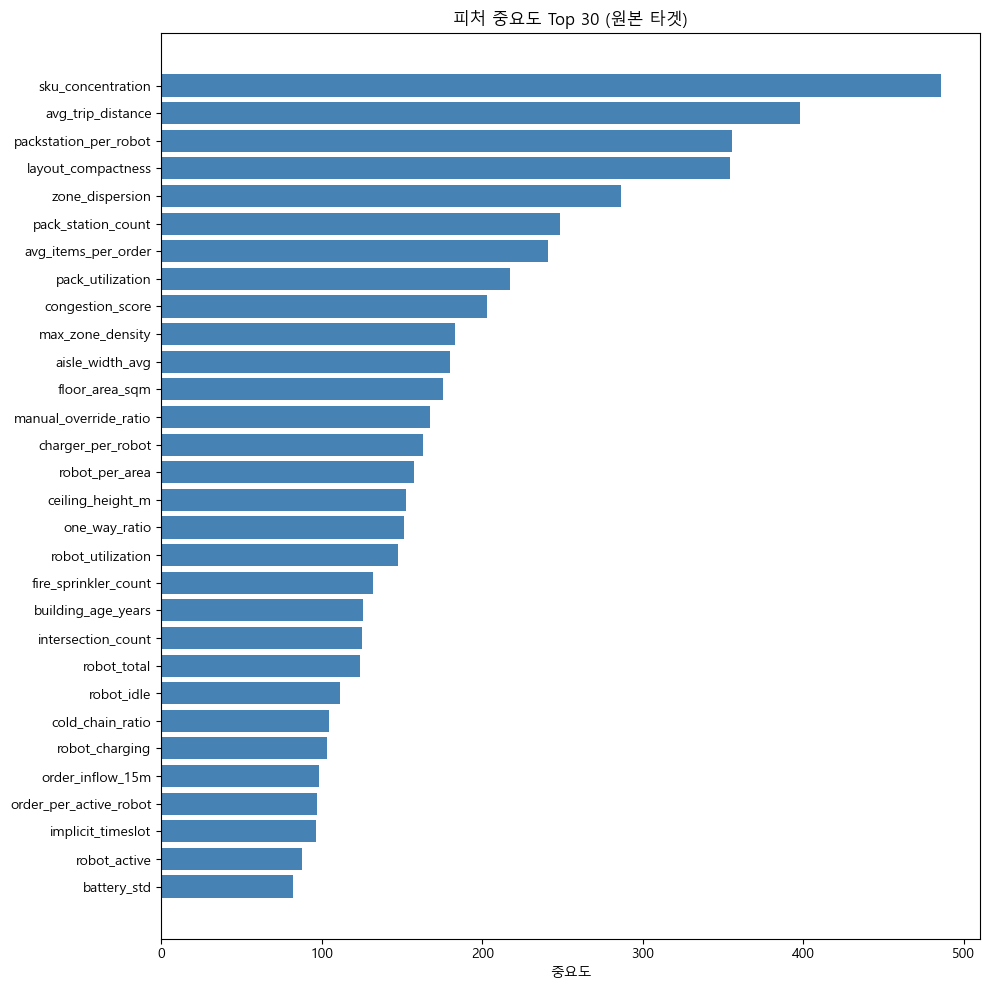

In [4]:
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': np.mean([m.feature_importances_ for m in models], axis=0)
}).sort_values('importance', ascending=False)

top30 = importance.head(30).sort_values('importance')

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(top30['feature'], top30['importance'], color='steelblue')
ax.set_title('피처 중요도 Top 30 (원본 타겟)')
ax.set_xlabel('중요도')
plt.tight_layout()
plt.savefig('../output/feature_importance_top30.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Submission 생성 (원본 타겟)

In [5]:
submission_raw = sample_sub.copy()
submission_raw['avg_delay_minutes_next_30m'] = np.clip(test_preds, 0, None)
submission_raw.to_csv('../output/submission_baseline.csv', index=False)

# 포맷 검증
assert list(submission_raw.columns) == list(sample_sub.columns), "컬럼 불일치!"
assert len(submission_raw) == len(sample_sub), "행 수 불일치!"
assert submission_raw['ID'].equals(sample_sub['ID']), "ID 불일치!"

print("submission_baseline.csv 생성 완료")
print(f"Shape: {submission_raw.shape}")
print(submission_raw.describe())

submission_baseline.csv 생성 완료
Shape: (50000, 2)
       avg_delay_minutes_next_30m
count                50000.000000
mean                    17.831074
std                     12.778251
min                      0.000000
25%                      5.389283
50%                     13.918763
75%                     32.132478
max                     43.003718


---\n# Phase 3: log1p 타겟 실험

In [6]:
y_log = np.log1p(y)

fold_maes_log = []
oof_preds_log = np.zeros(len(X))
test_preds_log = np.zeros(len(X_test))
models_log = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y_log, groups)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
    y_val_orig = y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train_log,
        eval_set=[(X_val, y_val_log)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
    )
    
    val_pred_log = model.predict(X_val)
    val_pred = np.expm1(val_pred_log)
    val_pred = np.clip(val_pred, 0, None)
    oof_preds_log[val_idx] = val_pred
    
    fold_mae = mean_absolute_error(y_val_orig, val_pred)
    fold_maes_log.append(fold_mae)
    
    test_pred_log = model.predict(X_test)
    test_preds_log += np.expm1(test_pred_log) / 5
    models_log.append(model)
    
    print(f"Fold {fold+1} MAE (log1p→expm1): {fold_mae:.4f}")

overall_mae_log = mean_absolute_error(y, oof_preds_log)
print(f"\n===== log1p 타겟 CV MAE: {overall_mae_log:.4f} =====")
print(f"Fold MAEs: {[f'{m:.4f}' for m in fold_maes_log]}")

print(f"\n===== 비교 =====")
print(f"원본 타겟 CV MAE: {overall_mae:.4f}")
print(f"log1p 타겟 CV MAE: {overall_mae_log:.4f}")
if overall_mae_log < overall_mae:
    print("→ log1p 타겟이 더 좋음!")
    best_test_preds = test_preds_log
    best_method = "log1p"
else:
    print("→ 원본 타겟이 더 좋음!")
    best_test_preds = test_preds
    best_method = "raw"

Fold 1 MAE (log1p→expm1): 9.3109


Fold 2 MAE (log1p→expm1): 9.1580


Fold 3 MAE (log1p→expm1): 9.7253


Fold 4 MAE (log1p→expm1): 8.6566


Fold 5 MAE (log1p→expm1): 9.0590

===== log1p 타겟 CV MAE: 9.1820 =====
Fold MAEs: ['9.3109', '9.1580', '9.7253', '8.6566', '9.0590']

===== 비교 =====
원본 타겟 CV MAE: 9.1901
log1p 타겟 CV MAE: 9.1820
→ log1p 타겟이 더 좋음!


## Best Submission 생성

In [7]:
submission_best = sample_sub.copy()
submission_best['avg_delay_minutes_next_30m'] = np.clip(best_test_preds, 0, None)
submission_best.to_csv('../output/submission_best.csv', index=False)

assert list(submission_best.columns) == list(sample_sub.columns), "컬럼 불일치!"
assert len(submission_best) == len(sample_sub), "행 수 불일치!"

print(f"submission_best.csv 생성 완료 (방법: {best_method})")
print(f"Shape: {submission_best.shape}")
print(submission_best.describe())

submission_best.csv 생성 완료 (방법: log1p)
Shape: (50000, 2)
       avg_delay_minutes_next_30m
count                50000.000000
mean                    17.630901
std                     12.959440
min                      0.000000
25%                      5.284918
50%                     13.077957
75%                     31.679838
max                     50.103338
